---
---
# TP1 — Construction et entraînement d'un UNet
---
---
**Objectif :** Construire un UNet, l'entraîner à débruiter des images de visages (CelebA-HQ 256×256), puis analyser les filtres appris par la première couche de convolution.

**Prérequis :** Python, PyTorch, notions de convolution (vues en cours).

**Durée estimée :** 2h

---

## 0. Imports et configuration

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

# Configuration
if torch.cuda.is_available() :
    device = torch.device('cuda')
elif torch.mps.is_available() :
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Device : {device}")

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

Device : mps


## 1. Chargement des données

On utilise le dataset CelebA-HQ (256×256). Les images sont dans le dossier `celeba_hq_256/`.

On les charge en niveaux de gris (1 canal) pour simplifier — c'est suffisant pour comprendre le UNet.

In [25]:
class CelebADataset(Dataset):
    """Dataset CelebA-HQ en niveaux de gris."""
    def __init__(self, root_dir, transform=None, max_images=2000):
        self.root_dir = Path(root_dir)
        extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
        self.image_paths = sorted([
            p for p in self.root_dir.iterdir()
            if p.suffix.lower() in extensions
        ])[:max_images]
        self.transform = transform
        print(f"Dataset : {len(self.image_paths)} images trouvées dans {root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('L')  # Niveaux de gris
        if self.transform:
            img = self.transform(img)
        return img

In [26]:
# Transformations : redimensionner à 128x128 (plus rapide à entraîner) et normaliser dans [0, 1]
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),  # Convertit en tenseur [0, 1]
])

dataset = CelebADataset('celeba_hq_256', transform=transform, max_images=2000)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0)

Dataset : 2000 images trouvées dans celeba_hq_256


Shape d'un batch : torch.Size([16, 1, 128, 128])


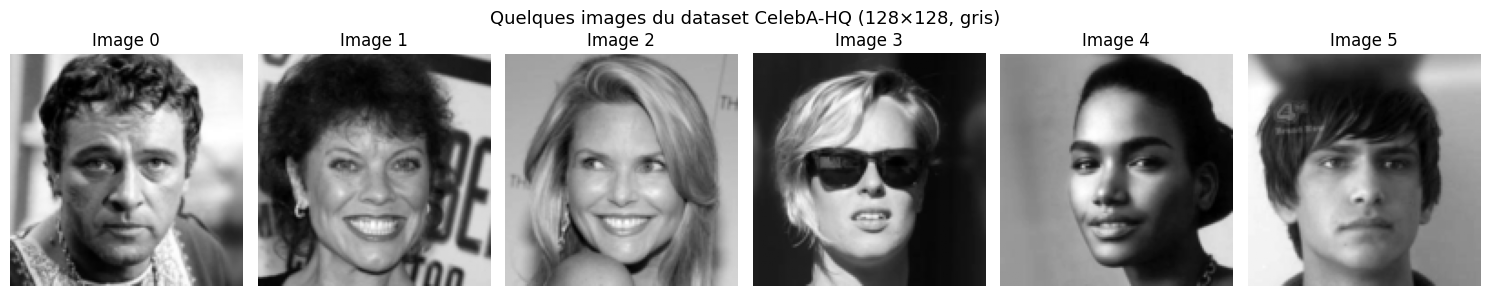

In [27]:
# Afficher quelques images du dataset
batch = next(iter(dataloader))
print(f"Shape d'un batch : {batch.shape}")  # (B, 1, 128, 128)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(batch[i, 0].numpy(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Image {i}')
plt.suptitle('Quelques images du dataset CelebA-HQ (128×128, gris)', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Le bruit : fabriquer des paires (bruitée, propre)

Pour entraîner notre UNet, on a besoin de **paires** :
- **Entrée** : image bruitée
- **Sortie attendue** : image propre

On ajoute du bruit gaussien à l'image propre :

$$\text{image\_bruitée} = \text{image\_propre} + \sigma \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, \mathbf{I})$$

**Question 1 :** Que se passe-t-il si $\sigma$ est très grand ? Très petit ?

In [28]:
def add_noise(images, sigma=0.2):
    """Ajoute du bruit gaussien à un batch d'images.
    
    Args:
        images: tenseur (B, 1, H, W) dans [0, 1]
        sigma: écart-type du bruit
    Returns:
        noisy: images bruitées, clampées dans [0, 1]
    """
    noise = torch.randn_like(images) * sigma
    noisy = images + noise
    return noisy.clamp(0, 1)

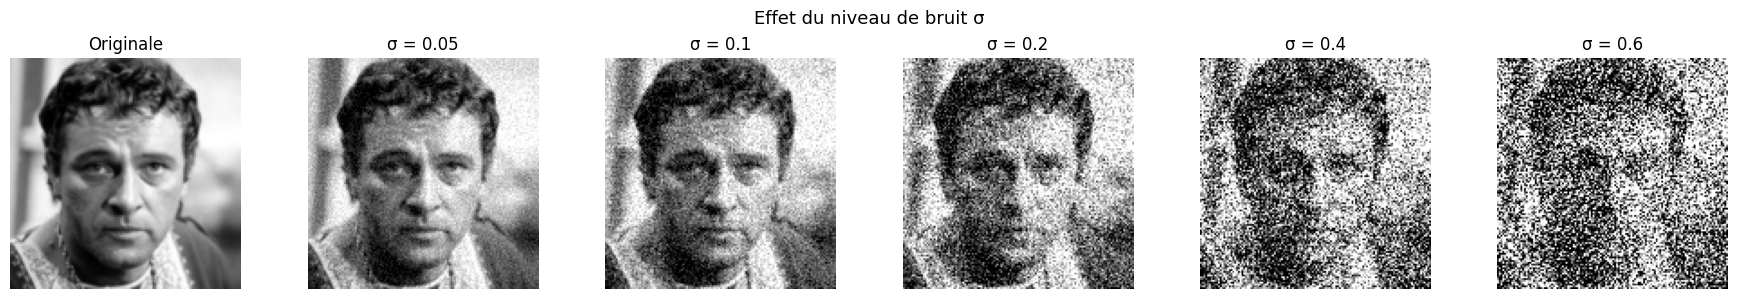

In [29]:
# Visualiser l'effet du bruit à différents niveaux
img = batch[0:1]  # Une seule image, shape (1, 1, 128, 128)

sigmas = [0.05, 0.1, 0.2, 0.4, 0.6]
fig, axes = plt.subplots(1, len(sigmas) + 1, figsize=(18, 3))
axes[0].imshow(img[0, 0].numpy(), cmap='gray')
axes[0].set_title('Originale')
axes[0].axis('off')

for i, s in enumerate(sigmas):
    noisy = add_noise(img, sigma=s)
    axes[i+1].imshow(noisy[0, 0].numpy(), cmap='gray')
    axes[i+1].set_title(f'σ = {s}')
    axes[i+1].axis('off')

plt.suptitle('Effet du niveau de bruit σ', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Construction du UNet

On construit le UNet étape par étape, exactement comme dans le cours :

1. **Encodeur** : Conv → Conv → MaxPool (répété 3 fois)
2. **Bottleneck** : Conv → Conv
3. **Décodeur** : Upsample → Concat (skip) → Conv → Conv (répété 3 fois)

### 3.1 Le bloc de convolution

Chaque étage utilise deux convolutions successives. Rappel du cours :
- La 1ère détecte des motifs simples
- La 2ème combine ces motifs (elle lit tous les canaux à la fois)

In [30]:
class ConvBlock(nn.Module):
    """Deux convolutions successives : Conv → ReLU → Conv → ReLU.
    
    C'est le bloc de base de chaque étage du UNet.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        return x

**Question 2 :** Dans `ConvBlock(1, 64)`, combien de poids a le filtre de `conv1` ? Et celui de `conv2` ?

*Indice : un filtre Conv2d(in, out, 3) a 3×3×in poids par filtre de sortie.*

### 3.2 Le UNet complet

**Question 3 :** Complétez la méthode `forward` du UNet. Les commentaires vous guident.

Rappel de l'architecture :
```
Entrée (1ch, 128×128)
  ↓ ConvBlock(1→32) → skip1 (32ch, 128×128)
  ↓ MaxPool
  ↓ ConvBlock(32→64) → skip2 (64ch, 64×64)
  ↓ MaxPool
  ↓ ConvBlock(64→128) → skip3 (128ch, 32×32)
  ↓ MaxPool
  ↓ ConvBlock(128→256)  ← Bottleneck (256ch, 16×16)
  ↑ Upsample + concat(skip3) → ConvBlock(256+128→128)
  ↑ Upsample + concat(skip2) → ConvBlock(128+64→64)
  ↑ Upsample + concat(skip1) → ConvBlock(64+32→32)
  → Conv1x1(32→1) → sortie (1ch, 128×128)
```

In [31]:
class UNet(nn.Module):
    """UNet pour le débruitage d'images en niveaux de gris."""
    
    def __init__(self):
        super().__init__()
        
        # --- Encodeur ---
        self.enc1 = ConvBlock(1, 32)      # 1 → 32 canaux
        self.enc2 = ConvBlock(32, 64)     # 32 → 64 canaux
        self.enc3 = ConvBlock(64, 128)    # 64 → 128 canaux
        self.pool = nn.MaxPool2d(2)       # Divise la taille par 2
        
        # --- Bottleneck ---
        self.bottleneck = ConvBlock(128, 256)  # 128 → 256 canaux
        
        # --- Décodeur ---
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)  # Upsample
        self.dec3 = ConvBlock(128 + 128, 128)  # 256 → 128 (après concat avec skip3)
        
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(64 + 64, 64)     # 128 → 64 (après concat avec skip2)
        
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(32 + 32, 32)     # 64 → 32 (après concat avec skip1)
        
        # --- Sortie ---
        self.out_conv = nn.Conv2d(32, 1, kernel_size=1)  # 32 → 1 canal
    
    def forward(self, x):
        # === ENCODEUR ===
        # Étage 1
        skip1 = self.enc1(x)          # (B, 32, 128, 128)
        x = self.pool(skip1)          # (B, 32, 64, 64)
        
        # Étage 2
        skip2 = self.enc2(x)          # (B, 64, 64, 64)
        x = self.pool(skip2)          # (B, 64, 32, 32)
        
        # Étage 3
        skip3 = self.enc3(x)          # (B, 128, 32, 32)
        x = self.pool(skip3)          # (B, 128, 16, 16)
        
        # === BOTTLENECK ===
        x = self.bottleneck(x)        # (B, 256, 16, 16)
        
        # === DÉCODEUR ===
        # Étage 3 (remontée)
        x = self.up3(x)                        # (B, 128, 32, 32)
        x = torch.cat([x, skip3], dim=1)       # (B, 256, 32, 32)  ← skip connection !
        x = self.dec3(x)                       # (B, 128, 32, 32)
        
        # Étage 2 (remontée)
        x = self.up2(x)                        # (B, 64, 64, 64)
        x = torch.cat([x, skip2], dim=1)       # (B, 128, 64, 64)
        x = self.dec2(x)                       # (B, 64, 64, 64)
        
        # Étage 1 (remontée)
        x = self.up1(x)                        # (B, 32, 128, 128)
        x = torch.cat([x, skip1], dim=1)       # (B, 64, 128, 128)
        x = self.dec1(x)                       # (B, 32, 128, 128)
        
        # === SORTIE ===
        x = self.out_conv(x)                   # (B, 1, 128, 128)
        return torch.sigmoid(x)                # Sortie dans [0, 1]

In [32]:
# Vérification : le réseau produit bien une image de même taille que l'entrée
model = UNet().to(device)
test_input = torch.randn(1, 1, 128, 128).to(device)
test_output = model(test_input)
print(f"Entrée  : {test_input.shape}")
print(f"Sortie  : {test_output.shape}")

# Nombre de paramètres
n_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres : {n_params:,}")

Entrée  : torch.Size([1, 1, 128, 128])
Sortie  : torch.Size([1, 1, 128, 128])
Nombre de paramètres : 1,925,025


## 4. Entraînement

On entraîne le UNet à **débruiter** : on lui donne une image bruitée, il doit retrouver l'image propre.

La loss est le MSE (Mean Squared Error) entre l'image propre et la sortie du réseau :

$$\mathcal{L} = \frac{1}{N} \sum_i \| \text{UNet}(\text{image\_bruitée}_i) - \text{image\_propre}_i \|^2$$

**Question 4 :** Pourquoi utilise-t-on le MSE et pas une autre loss ?

In [33]:
# Hyperparamètres
EPOCHS = 20
LR = 5e-3
NOISE_SIGMA = 0.2  # Niveau de bruit

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

In [34]:
# Boucle d'entraînement
losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    n_batches = 0
    
    for clean in dataloader:
        clean = clean.to(device)                       # Image propre
        noisy = add_noise(clean, sigma=NOISE_SIGMA)    # Image bruitée
        
        # Forward
        output = model(noisy)
        loss = criterion(output, clean)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} — Loss : {avg_loss:.6f}")

print("\nEntraînement terminé !")

Epoch  1/20 — Loss : 0.012082
Epoch  2/20 — Loss : 0.003092
Epoch  3/20 — Loss : 0.002943
Epoch  4/20 — Loss : 0.002833
Epoch  5/20 — Loss : 0.002775
Epoch  6/20 — Loss : 0.002668
Epoch  7/20 — Loss : 0.002589
Epoch  8/20 — Loss : 0.002500
Epoch  9/20 — Loss : 0.002431
Epoch 10/20 — Loss : 0.002375
Epoch 11/20 — Loss : 0.002299
Epoch 12/20 — Loss : 0.002274
Epoch 13/20 — Loss : 0.002246
Epoch 14/20 — Loss : 0.002259
Epoch 15/20 — Loss : 0.002201
Epoch 16/20 — Loss : 0.002200
Epoch 17/20 — Loss : 0.002172
Epoch 18/20 — Loss : 0.002168
Epoch 19/20 — Loss : 0.002151
Epoch 20/20 — Loss : 0.002147

Entraînement terminé !


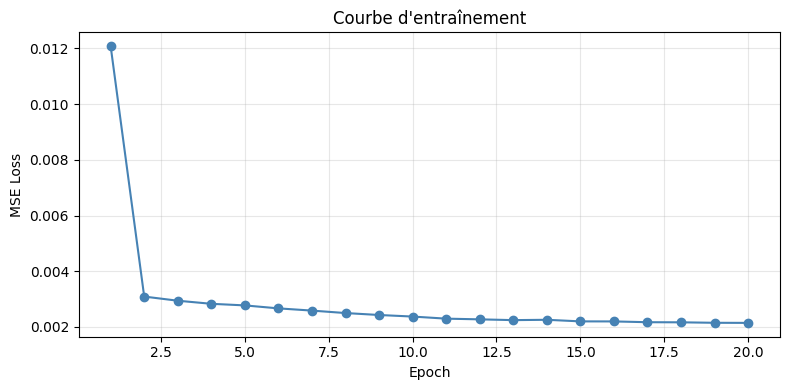

In [35]:
# Courbe de loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), losses, 'o-', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Courbe d\'entraînement')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Résultats de débruitage

Regardons ce que le UNet a appris à faire.

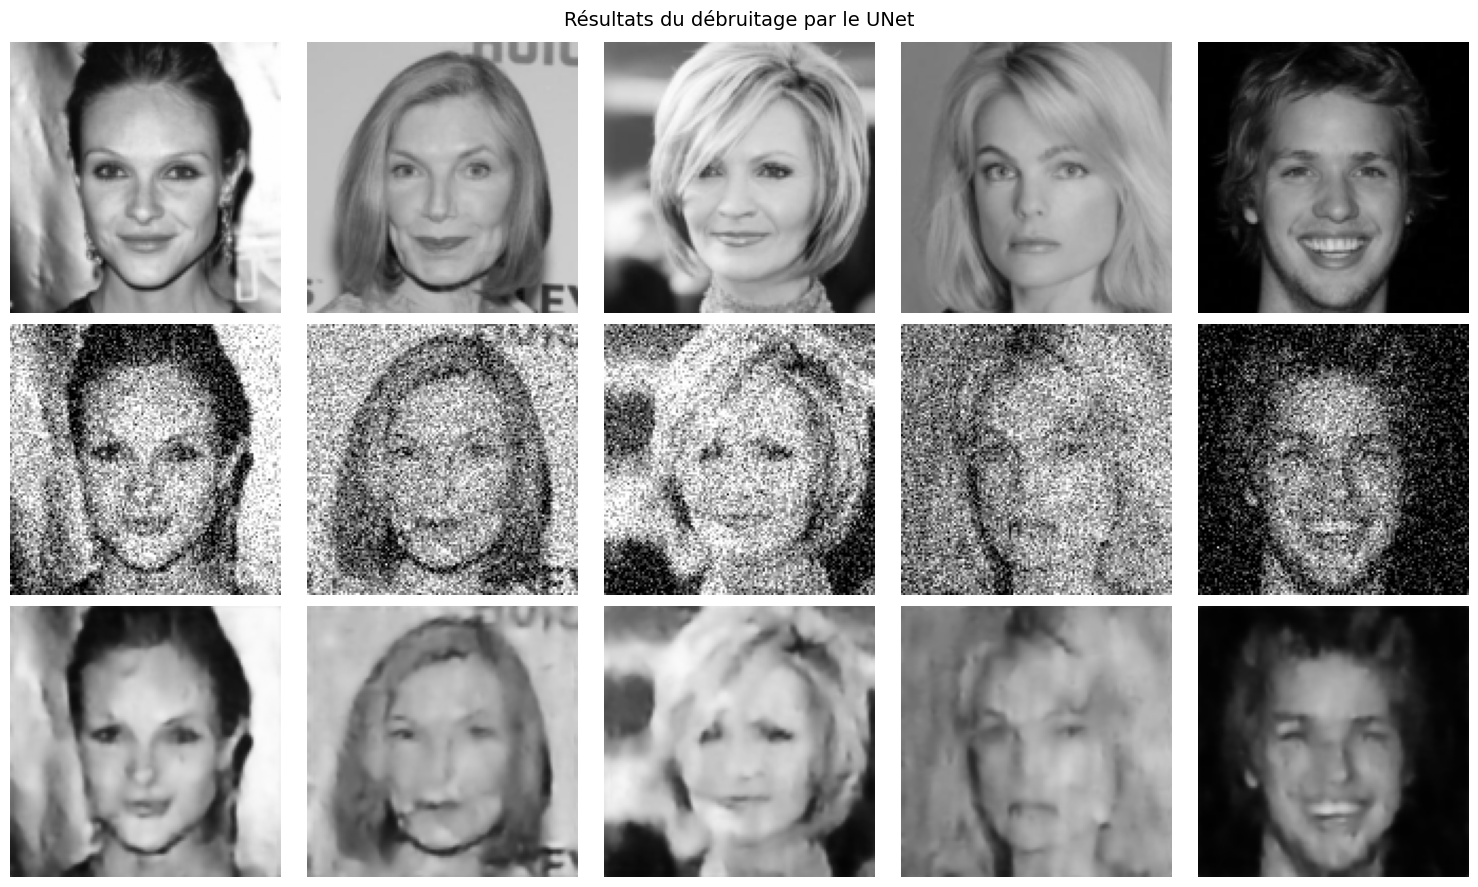

In [36]:
# Prendre un batch d'images qu'on n'a pas forcément vues à l'entraînement
model.eval()
test_batch = next(iter(dataloader)).to(device)
noisy_batch = add_noise(test_batch, sigma=NOISE_SIGMA)

with torch.no_grad():
    denoised_batch = model(noisy_batch)

# Affichage : propre / bruitée / débruitée
n_show = 5
fig, axes = plt.subplots(3, n_show, figsize=(15, 9))
titles_row = ['Image propre', 'Image bruitée (σ=0.2)', 'Sortie du UNet']

for i in range(n_show):
    axes[0, i].imshow(test_batch[i, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(noisy_batch[i, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[2, i].imshow(denoised_batch[i, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)

for row, title in enumerate(titles_row):
    axes[row, 0].set_ylabel(title, fontsize=12)

for ax in axes.flat:
    ax.axis('off')

plt.suptitle('Résultats du débruitage par le UNet', fontsize=14)
plt.tight_layout()
plt.show()

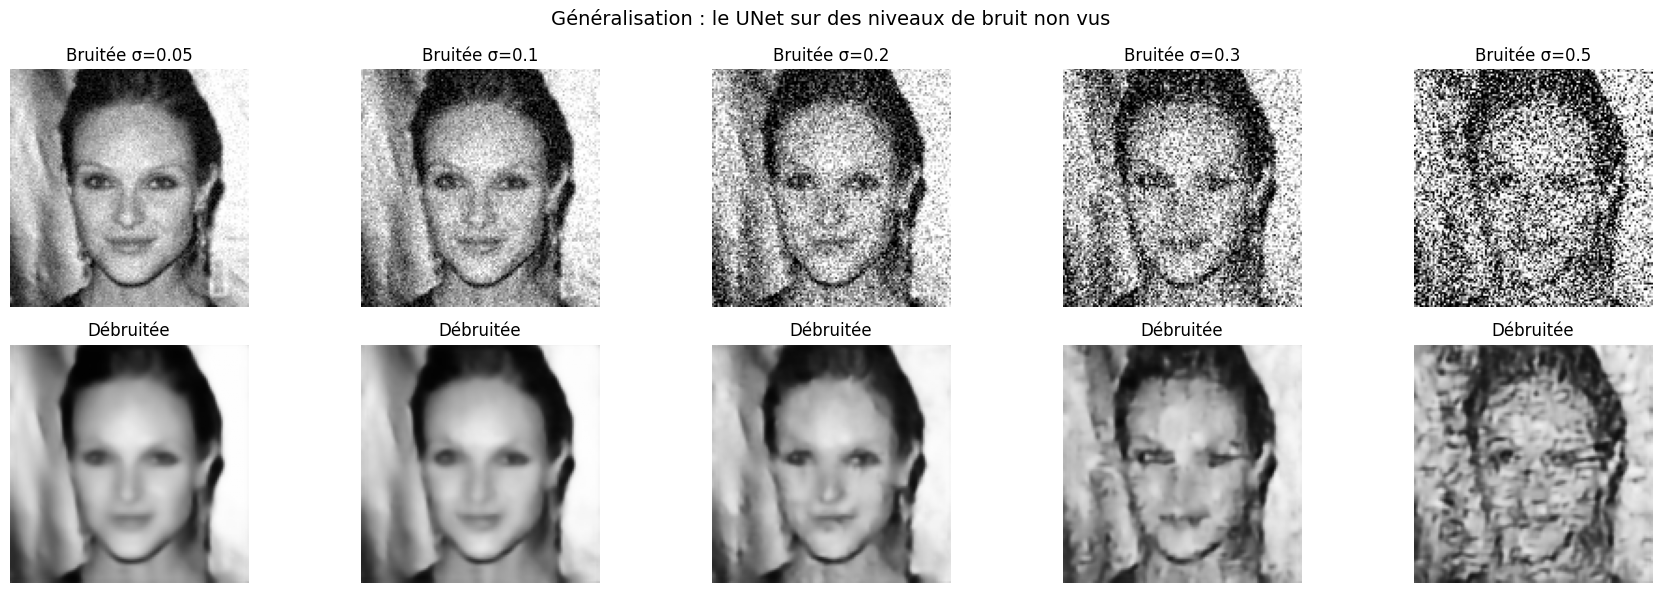

In [37]:
# Test avec différents niveaux de bruit (le modèle a été entraîné avec σ=0.2)
test_img = test_batch[0:1]
test_sigmas = [0.05, 0.1, 0.2, 0.3, 0.5]

fig, axes = plt.subplots(2, len(test_sigmas), figsize=(18, 6))

for i, s in enumerate(test_sigmas):
    noisy = add_noise(test_img, sigma=s)
    with torch.no_grad():
        denoised = model(noisy)
    
    axes[0, i].imshow(noisy[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Bruitée σ={s}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(denoised[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'Débruitée')
    axes[1, i].axis('off')

plt.suptitle('Généralisation : le UNet sur des niveaux de bruit non vus', fontsize=14)
plt.tight_layout()
plt.show()

**Question 5 :** Le UNet se comporte-t-il bien pour σ=0.05 ? Pour σ=0.5 ? Pourquoi ?

## 6. Analyse des filtres de la première couche

Maintenant, regardons **ce que le réseau a appris** dans sa toute première couche de convolution.

Rappel du cours : la première conv est `Conv2d(1, 32, 3)` — elle a **32 filtres** de taille 3×3, chacun avec **9 poids**.

La question : est-ce que ces filtres ressemblent à des filtres connus (Sobel, Laplacien, moyenneur...) ou est-ce que le réseau a trouvé autre chose ?

In [38]:
# Extraire les poids de la première convolution (enc1.conv1)
first_conv_weights = model.enc1.conv1.weight.data.cpu()  # Shape : (32, 1, 3, 3)
print(f"Shape des poids : {first_conv_weights.shape}")
print(f"→ {first_conv_weights.shape[0]} filtres de taille {first_conv_weights.shape[2]}×{first_conv_weights.shape[3]}")

Shape des poids : torch.Size([32, 1, 3, 3])
→ 32 filtres de taille 3×3


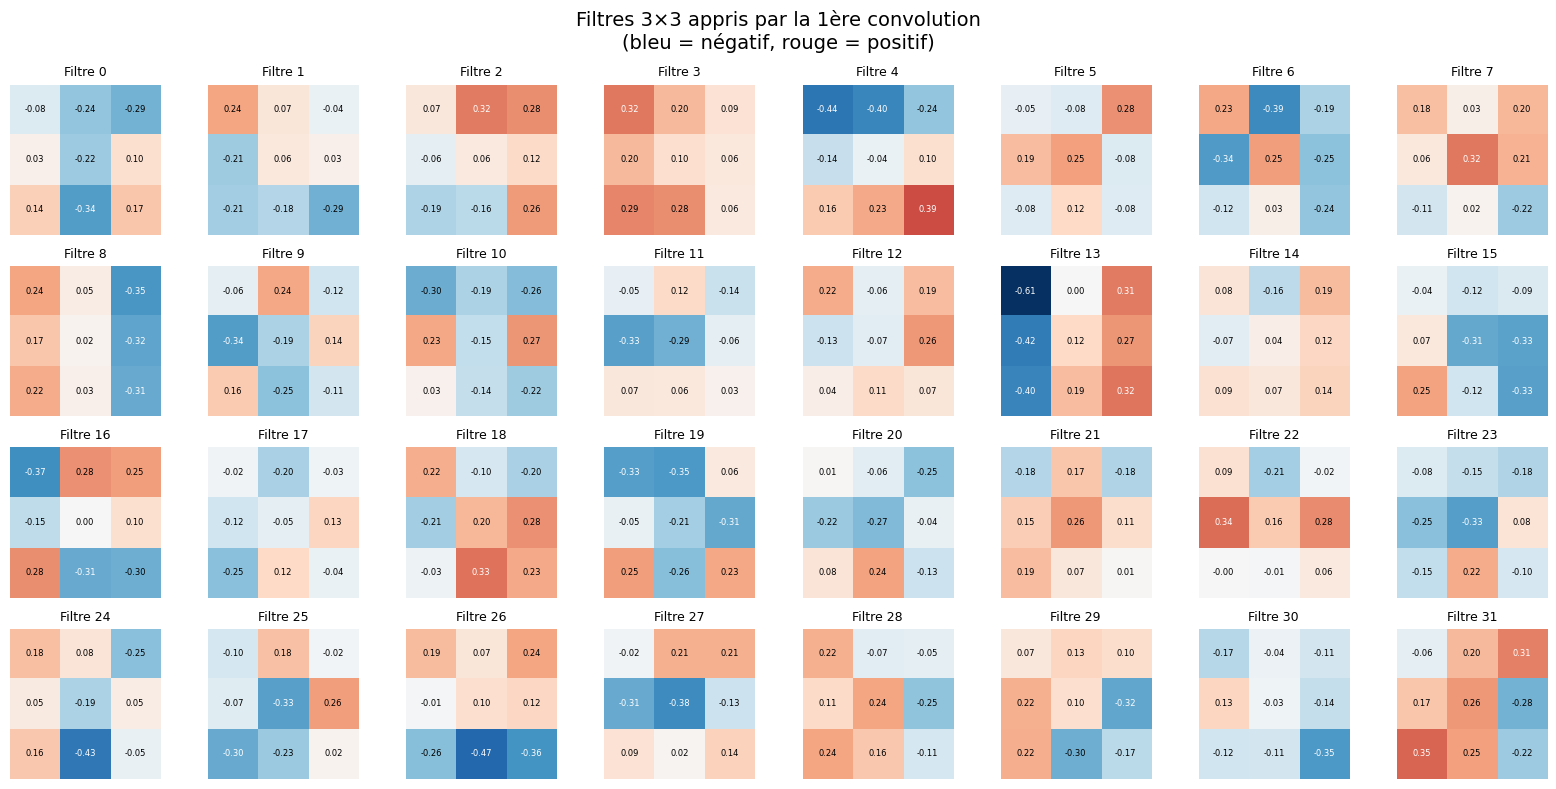

In [39]:
# Visualiser les 32 filtres appris
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

# Trouver les valeurs min/max pour une échelle de couleur commune
vmin = first_conv_weights.min().item()
vmax = first_conv_weights.max().item()
vabs = max(abs(vmin), abs(vmax))

for i, ax in enumerate(axes.flat):
    kernel = first_conv_weights[i, 0].numpy()  # (3, 3)
    im = ax.imshow(kernel, cmap='RdBu_r', vmin=-vabs, vmax=vabs)
    ax.set_title(f'Filtre {i}', fontsize=9)
    ax.axis('off')
    
    # Afficher les valeurs dans chaque case
    for row in range(3):
        for col in range(3):
            ax.text(col, row, f'{kernel[row, col]:.2f}',
                    ha='center', va='center', fontsize=6,
                    color='black' if abs(kernel[row, col]) < vabs * 0.5 else 'white')

plt.suptitle('Filtres 3×3 appris par la 1ère convolution\n(bleu = négatif, rouge = positif)', fontsize=14)
plt.tight_layout()
plt.show()

**Question 6 :** Regardez attentivement les filtres ci-dessus.

1. Certains filtres ressemblent-ils à des **détecteurs de contours** (type Sobel) ? Lesquels ?
2. Certains filtres ressemblent-ils à un **moyenneur** (type flou) ? Lesquels ?
3. Y a-t-il des filtres que vous ne reconnaissez pas ? Qu'est-ce qu'ils pourraient détecter ?

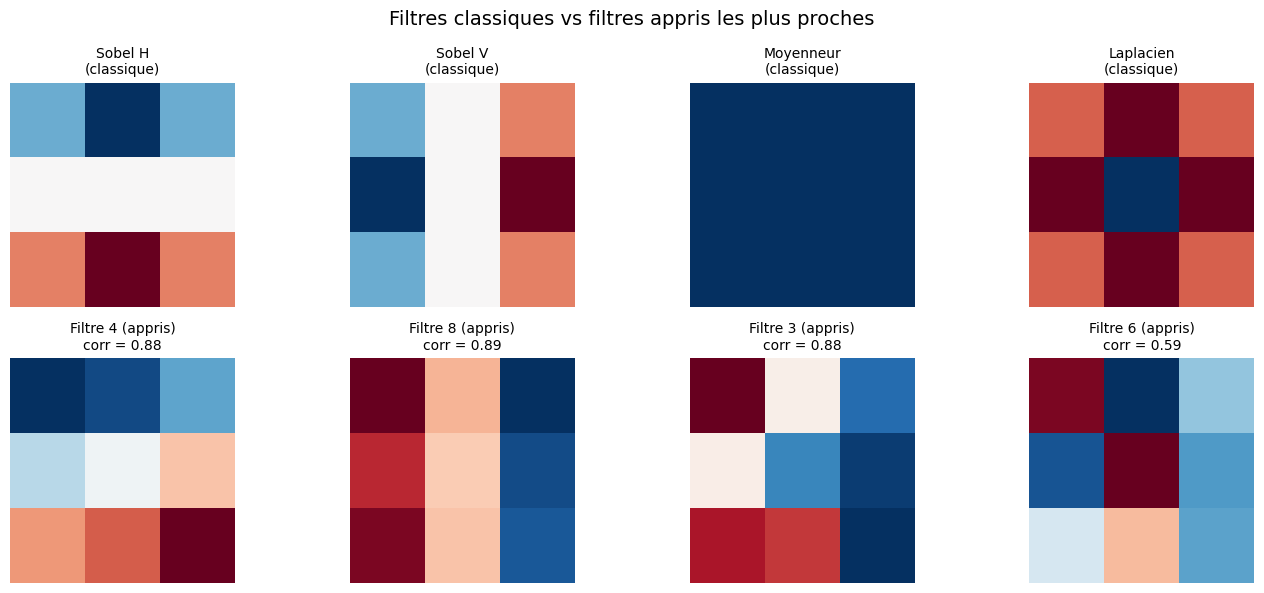

In [40]:
# Comparaison : filtres classiques vs filtres appris
# On affiche côte à côte les filtres de Sobel et les filtres appris les plus similaires

sobel_h = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
sobel_v = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
average = np.ones((3, 3), dtype=np.float32) / 9
laplacian = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)

classic_filters = {
    'Sobel H': sobel_h,
    'Sobel V': sobel_v,
    'Moyenneur': average,
    'Laplacien': laplacian,
}

# Pour chaque filtre classique, trouver le filtre appris le plus similaire
# (en termes de corrélation normalisée)
fig, axes = plt.subplots(2, len(classic_filters), figsize=(14, 6))

for j, (name, classic) in enumerate(classic_filters.items()):
    # Normaliser le filtre classique
    classic_norm = classic / (np.linalg.norm(classic) + 1e-8)
    
    # Chercher le filtre appris le plus corrélé
    best_corr = -1
    best_idx = 0
    for i in range(32):
        learned = first_conv_weights[i, 0].numpy()
        learned_norm = learned / (np.linalg.norm(learned) + 1e-8)
        corr = abs(np.sum(classic_norm * learned_norm))
        if corr > best_corr:
            best_corr = corr
            best_idx = i
    
    # Afficher
    axes[0, j].imshow(classic, cmap='RdBu_r')
    axes[0, j].set_title(f'{name}\n(classique)', fontsize=10)
    axes[0, j].axis('off')
    
    learned_best = first_conv_weights[best_idx, 0].numpy()
    axes[1, j].imshow(learned_best, cmap='RdBu_r')
    axes[1, j].set_title(f'Filtre {best_idx} (appris)\ncorr = {best_corr:.2f}', fontsize=10)
    axes[1, j].axis('off')

plt.suptitle('Filtres classiques vs filtres appris les plus proches', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Visualiser ce que "voit" chaque filtre

Pour mieux comprendre, on peut appliquer chaque filtre à une image et regarder le résultat (la **feature map**).

In [41]:
# Passer une image dans la première conv et récupérer les 32 feature maps
model.eval()
sample_img = test_batch[0:1].to(device)  # (1, 1, 128, 128)

with torch.no_grad():
    # Appliquer seulement la première conv + ReLU
    feature_maps = model.enc1.relu(model.enc1.conv1(sample_img))  # (1, 32, 128, 128)

feature_maps = feature_maps.cpu()
print(f"Shape des feature maps : {feature_maps.shape}")

Shape des feature maps : torch.Size([1, 32, 128, 128])


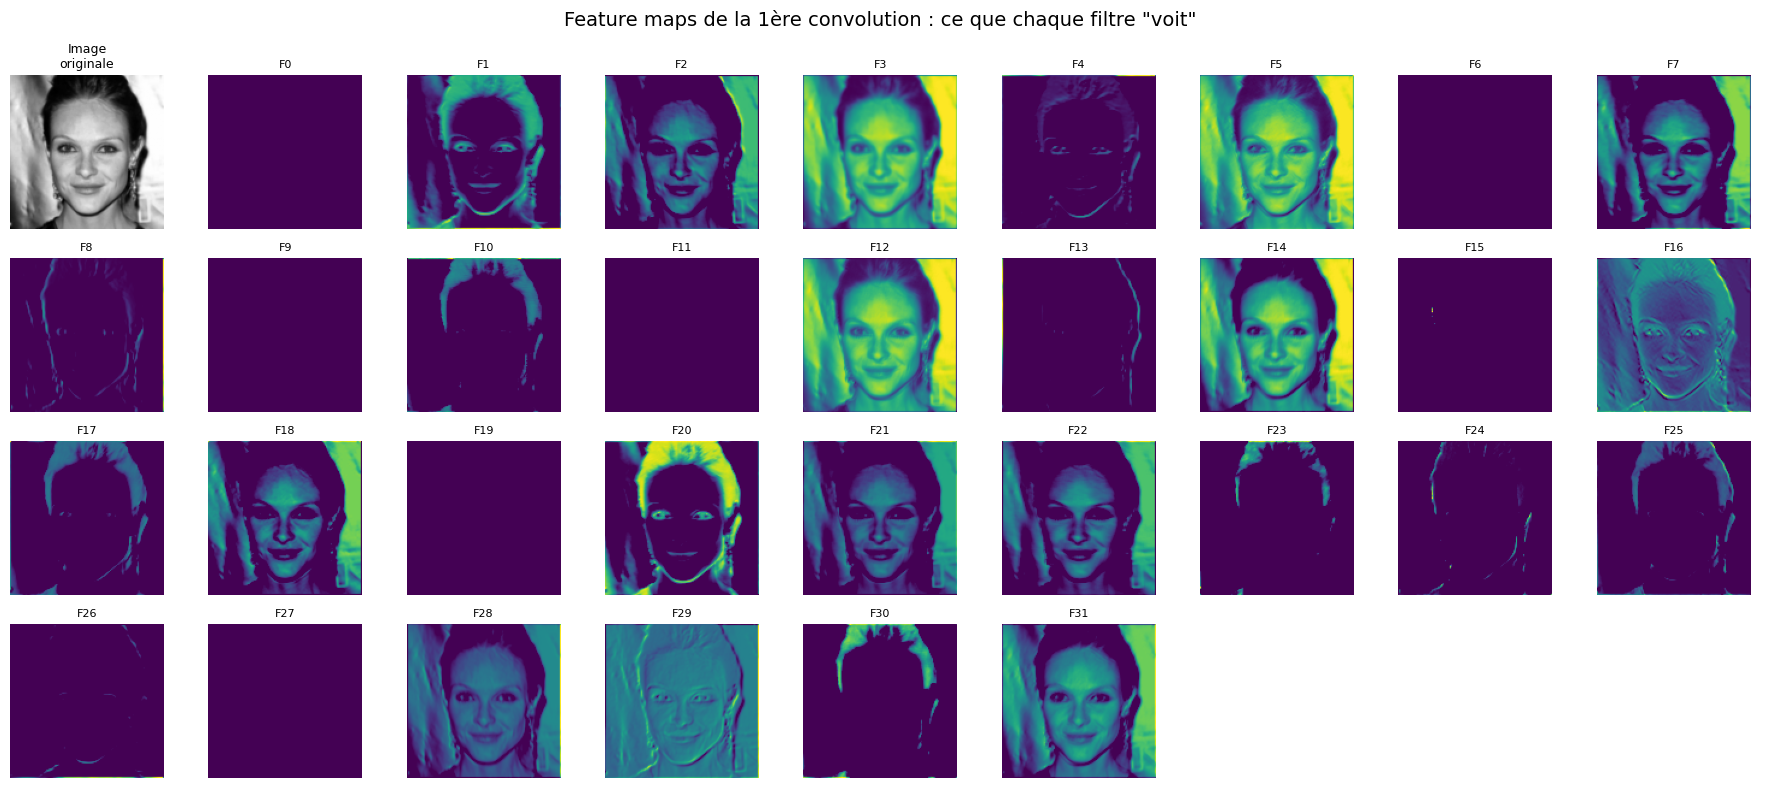

In [42]:
# Afficher l'image originale + les 32 feature maps
fig, axes = plt.subplots(4, 9, figsize=(18, 8))

# Image originale en premier
axes[0, 0].imshow(sample_img[0, 0].cpu().numpy(), cmap='gray')
axes[0, 0].set_title('Image\noriginale', fontsize=9)
axes[0, 0].axis('off')

# Les 32 feature maps
for i in range(32):
    row = (i + 1) // 9
    col = (i + 1) % 9
    fmap = feature_maps[0, i].numpy()
    axes[row, col].imshow(fmap, cmap='viridis')
    axes[row, col].set_title(f'F{i}', fontsize=8)
    axes[row, col].axis('off')

# Cacher les axes restants
for i in range(33, 36):
    row = i // 9
    col = i % 9
    axes[row, col].axis('off')

plt.suptitle('Feature maps de la 1ère convolution : ce que chaque filtre "voit"', fontsize=14)
plt.tight_layout()
plt.show()

**Question 7 (bonus) :** En regardant les feature maps :
1. Lesquelles semblent détecter des **contours** (zones claires le long des bords du visage) ?
2. Lesquelles semblent détecter des **zones uniformes** (le fond, la peau) ?
3. Y a-t-il des feature maps qui semblent inutiles (presque noires ou uniformes) ?

---

## Conclusion

Dans ce TP, vous avez :
1. Construit un **UNet** de A à Z (encodeur + bottleneck + décodeur + skip connections)
2. Entraîné ce réseau à **débruiter** des images de visages
3. Analysé les **filtres appris** et constaté qu'ils ressemblent à des opérateurs classiques (Sobel, moyenneur, Laplacien)
4. Visualisé les **feature maps** pour comprendre ce que chaque filtre détecte

**Ce qu'on retient :** le réseau retrouve **tout seul** des filtres que les ingénieurs avaient conçus à la main, et il en découvre d'autres, adaptés spécifiquement à la tâche de débruitage de visages.

Dans la suite du cours, on verra comment ce même UNet peut être utilisé pour **générer** de nouvelles images (modèle de diffusion).